# Práctica 2: Detección de Outliers

- Victor Osuna
- Emanuel Pacheco
- Aldair Valerio

## Objetivo de la práctica

Esta práctica estudia la detección de anomalías en una bomba de agua monitorizada mediante 52 sensores. El conjunto de datos contiene más de 220.000 observaciones temporales, lo que permite analizar el problema desde dos escenarios complementarios:

- **Offline o batch**: el modelo dispone del histórico completo y puede construir su criterio de decisión con toda la información disponible.
- **Online o streaming**: el modelo procesa las observaciones una a una, simulando un entorno de monitorización en tiempo real.

El propósito del notebook es desarrollar una visión completa del problema: preparar los datos, entender la estructura del sistema, aplicar distintas técnicas de detección y comparar su comportamiento según el contexto de uso.

## Estrategia metodológica

### 1. Uso del conjunto completo de sensores

La detección de anomalías se plantea como un problema **multivariante**. Aunque algunas señales individuales pueden resultar más informativas o más fáciles de visualizar, una anomalía operativa no siempre aparece como una desviación evidente en un único sensor. En muchos casos, el comportamiento anómalo surge en la relación entre varias variables del proceso.

Por esa razón, los modelos se entrenan y evalúan con el **conjunto completo de sensores útiles tras la limpieza**, preservando la mayor cantidad posible de información del sistema.

### 2. Familias de métodos consideradas

La práctica compara varias familias de detectores para cubrir enfoques complementarios, además de considerar los métodos offline y online:
## Offline
- **IQR batch**: regla estadística robusta basada en rangos intercuartílicos.
- **Z-Score batch**: referencia clásica basada en media y desviación estándar.
- **K-Means batch**: enfoque multivariante que identifica observaciones alejadas de los centroides.
- **Isolation Forest**: método específico para detección de anomalías sobre datos históricos.
## Online
- **IQR online**: adaptación del criterio por cuartiles a una ventana móvil.
- **Z-Score online**: adaptación progresiva con estadísticas actualizadas en el tiempo.
- **K-Means online**: clustering incremental para flujo de datos.
- **Half-Space Trees**: detector diseñado para escenarios streaming.

### 3. Métricas de evaluación

Dado que las anomalías representan eventos minoritarios pero relevantes, la evaluación no puede basarse solo en cuántas observaciones se clasifican correctamente en total. En esta práctica se priorizan:

- **Recall**: capacidad para recuperar anomalías reales.
- **Precision**: proporción de alertas que realmente corresponden a anomalías.
- **F1-Score**: balance entre precision y recall.

Además, se consideran tiempos de ejecución para valorar si cada técnica resulta viable en un entorno operativo.

In [1]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from river import anomaly, cluster, preprocessing as river_prep
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_DIR = Path.cwd()
SEARCH_ROOTS = [PROJECT_DIR, *PROJECT_DIR.parents]

DATA_PATH = None
for root in SEARCH_ROOTS:
    candidate = root / "sensor.csv"
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError("No se encontró sensor.csv en el árbol de directorios accesible desde el notebook.")

BENCHMARK_PATH = PROJECT_DIR / "benchmark_results.csv"
PREDICTIONS_PATH = PROJECT_DIR / "predictions_best.csv"
PLOTS_DIR = PROJECT_DIR / "plots"

print(f"Directorio de trabajo del notebook: {PROJECT_DIR}")
print(f"Dataset utilizado: {DATA_PATH}")
print(f"Benchmark encontrado: {BENCHMARK_PATH.exists()}")
print(f"Predicciones encontradas: {PREDICTIONS_PATH.exists()}")

Directorio de trabajo del notebook: c:\Users\aldav\OneDrive\Documentos\IA_AVANZADA\Practica 2\P2_Workflows_Outliers\Vic_P2\P2_Workflows_Outliers
Dataset utilizado: c:\Users\aldav\OneDrive\Documentos\IA_AVANZADA\Practica 2\P2_Workflows_Outliers\Vic_P2\P2_Workflows_Outliers\sensor.csv
Benchmark encontrado: True
Predicciones encontradas: True


## Carga de datos y definición de anomalía

Antes de aplicar cualquier detector, es necesario decidir qué estados del sistema se tratarán como comportamiento anómalo. En este notebook se adopta una definición amplia:

- **BROKEN** representa el fallo explícito del sistema.
- **RECOVERING** representa una fase transitoria en la que la bomba todavía no opera de forma completamente normal.

Agrupar ambos estados como anomalía permite estudiar no solo el fallo final, sino también el comportamiento no estable asociado a la recuperación del proceso. Esta decisión lo hace que vaya acorde a un posible un escenario industrial, donde interesa detectar cualquier régimen operativo alejado de la normalidad.

La preparación de datos sigue una secuencia estándar para asegurar consistencia en el análisis:

- eliminar columnas auxiliares que no aportan información al modelado,
- convertir la marca temporal a índice de tiempo,
- eliminar registros duplicados,
- descartar el sensor con ausencia extrema de datos,
- rellenar valores faltantes mediante propagación hacia delante y, si todavía quedan huecos, con cero.

Con esta base, el conjunto final queda listo para estudiar tanto patrones globales como detectores de anomalías.

In [2]:
def load_data(csv_path: Path, anomaly_labels=None):
    if anomaly_labels is None:
        anomaly_labels = ["BROKEN", "RECOVERING"]

    df = pd.read_csv(csv_path)
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp")

    if "machine_status" in df.columns:
        df["is_anomaly_real"] = df["machine_status"].isin(anomaly_labels).astype(int)

    df = df.drop_duplicates()
    df = df.drop(columns=["sensor_15"], errors="ignore")

    sensor_columns = df.filter(regex="sensor_").columns.tolist()
    df[sensor_columns] = df[sensor_columns].ffill().fillna(0)

    return df[sensor_columns].copy(), df.copy(), df["is_anomaly_real"].to_numpy()

PRIMARY_LABELS = ["BROKEN", "RECOVERING"]
df_sensors, df_full, y_true = load_data(DATA_PATH, anomaly_labels=PRIMARY_LABELS)

status_counts = df_full["machine_status"].value_counts(dropna=False).rename("count")
summary_df = pd.DataFrame({
    "n_muestras": [len(df_full)],
    "n_sensores_utilizados": [df_sensors.shape[1]],
    "n_anomalias": [int(y_true.sum())],
    "porcentaje_anomalias": [round(100 * y_true.mean(), 4)],
    "definicion_anomalia": [" + ".join(PRIMARY_LABELS)],
})

display(summary_df)
display(status_counts.to_frame())

,n_muestras,n_sensores_utilizados,n_anomalias,porcentaje_anomalias,definicion_anomalia
0,217444,51,14275,6.5649,BROKEN + RECOVERING


,count
machine_status,
NORMAL,203169
RECOVERING,14268
BROKEN,7


## Exploración inicial del conjunto de datos

Antes de comparar detectores de anomalías, conviene entender tres aspectos del problema:

1. **Distribución temporal y proporción de estados**: permite dimensionar el desbalance de clases.
2. **Estructura global de los sensores**: ayuda a ver si las anomalías tienen cierta separabilidad en un espacio reducido.
3. **Relación entre sensores**: justifica qué sensor usar como referencia visual y confirma si tiene sentido tratar el problema de forma multivariante.

La exploración que sigue no sustituye al modelado, pero sí permite argumentar decisiones posteriores.

,n_missing_top10_antes_de_limpieza
sensor_15,220320
sensor_50,77017
sensor_51,15383
sensor_00,10208
sensor_07,5451
sensor_08,5107
sensor_06,4798
sensor_09,4595
sensor_01,369
sensor_30,261


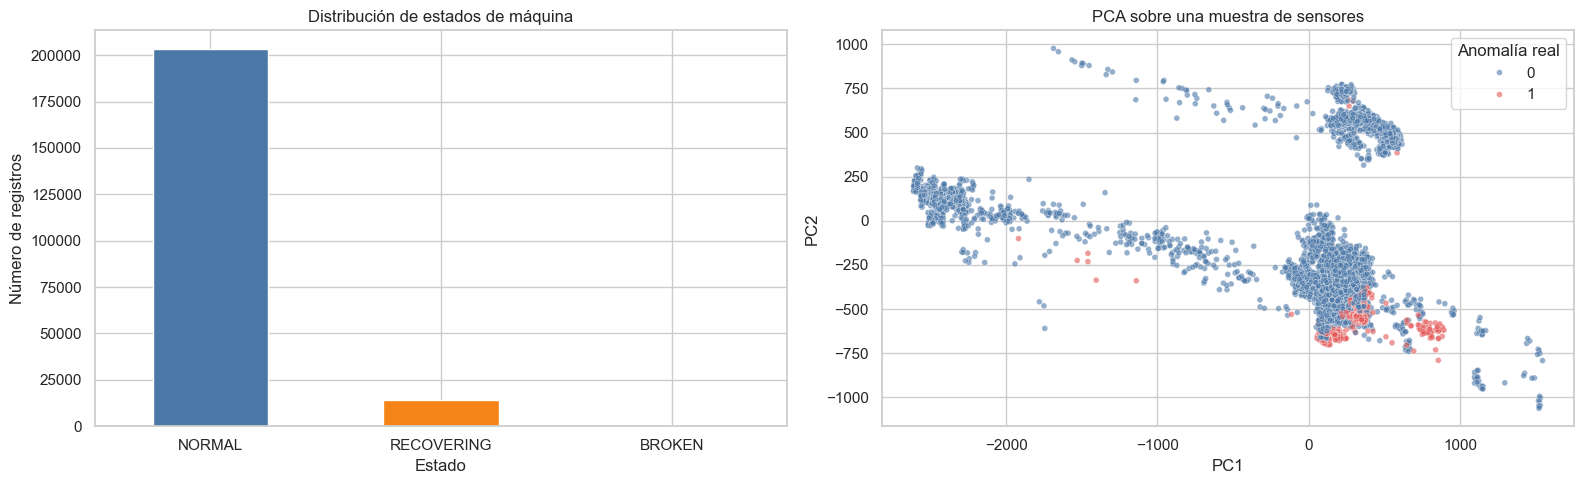

In [3]:
missing_before = pd.read_csv(DATA_PATH).isna().sum().sort_values(ascending=False).head(10)
display(missing_before.to_frame(name="n_missing_top10_antes_de_limpieza"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

status_counts.plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518", "#e45756"][:len(status_counts)])
axes[0].set_title("Distribución de estados de máquina")
axes[0].set_xlabel("Estado")
axes[0].set_ylabel("Número de registros")
axes[0].tick_params(axis="x", rotation=0)

sample_size = min(10000, len(df_sensors))
sample_idx = np.linspace(0, len(df_sensors) - 1, sample_size, dtype=int)
pca = PCA(n_components=2)
pca_points = pca.fit_transform(df_sensors.iloc[sample_idx])
pca_df = pd.DataFrame(pca_points, columns=["PC1", "PC2"])
pca_df["is_anomaly_real"] = y_true[sample_idx]

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="is_anomaly_real",
    palette={0: "#4c78a8", 1: "#e45756"},
    alpha=0.6,
    s=18,
    ax=axes[1],
)
axes[1].set_title("PCA sobre una muestra de sensores")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title="Anomalía real")

plt.tight_layout()
plt.show()

## Selección del sensor de referencia

Aunque el modelado se realiza con múltiples sensores, resulta útil disponer de una señal de referencia para interpretar visualmente la dinámica temporal del sistema. Para ello, se calcula la correlación media absoluta entre sensores y se elige como referencia la señal más conectada con el comportamiento global del conjunto.

Esta elección debe entenderse correctamente:

- **No implica** reducir el problema a una sola variable.
- **Sí permite** disponer de una señal representativa para visualizar cambios, transiciones y zonas anómalas con mayor claridad.

De este modo, el análisis mantiene la riqueza multivariante para detectar anomalías, pero utiliza un sensor de referencia para mejorar la interpretación de las gráficas temporales.

,correlacion_media_absoluta
sensor_23,0.410419
sensor_22,0.403666
sensor_19,0.400407
sensor_21,0.400168
sensor_20,0.399657
sensor_24,0.399378
sensor_16,0.396203
sensor_25,0.395404
sensor_14,0.393437
sensor_26,0.393043


Sensor de referencia seleccionado: sensor_23


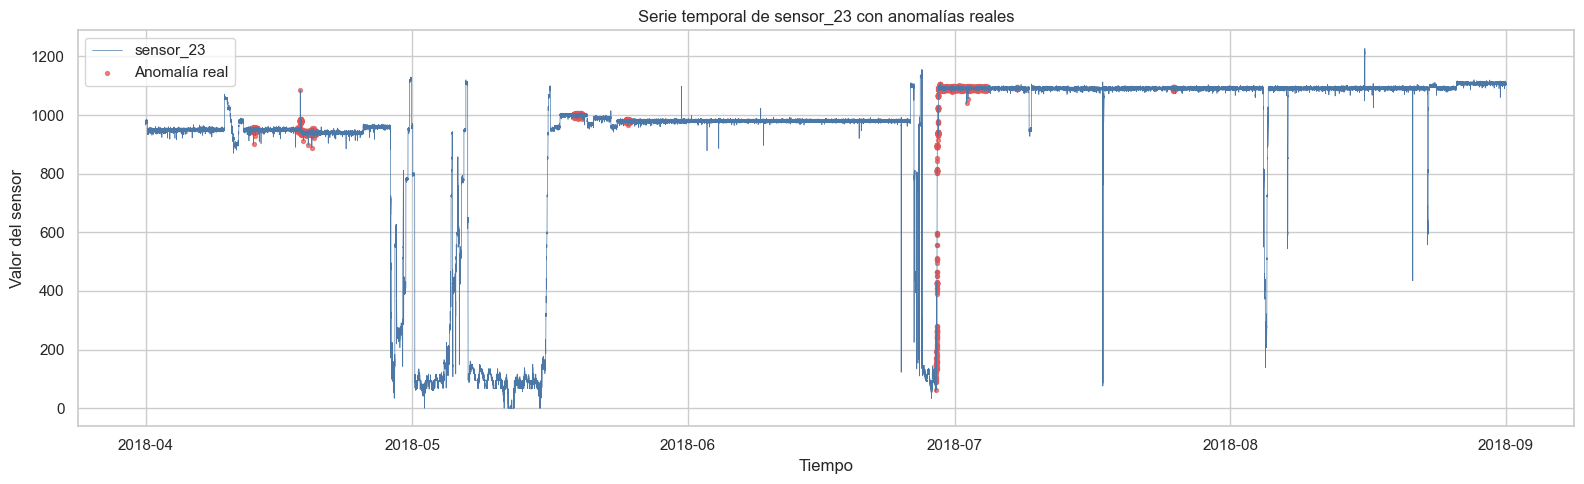

In [4]:
corr_sensors = df_sensors.corr()
np.fill_diagonal(corr_sensors.values, np.nan)
mean_abs_corr = corr_sensors.abs().mean().sort_values(ascending=False)

reference_sensor = mean_abs_corr.index[0]
display(mean_abs_corr.head(10).to_frame(name="correlacion_media_absoluta"))
print(f"Sensor de referencia seleccionado: {reference_sensor}")

plt.figure(figsize=(16, 5))
plt.plot(df_sensors.index, df_sensors[reference_sensor], color="#4c78a8", linewidth=0.5, label=reference_sensor)
anom_idx = df_full.index[df_full["is_anomaly_real"] == 1]
plt.scatter(
    anom_idx,
    df_sensors.loc[anom_idx, reference_sensor],
    color="#e45756",
    s=8,
    alpha=0.7,
    label="Anomalía real",
)
plt.title(f"Serie temporal de {reference_sensor} con anomalías reales")
plt.xlabel("Tiempo")
plt.ylabel("Valor del sensor")
plt.legend()
plt.tight_layout()
plt.show()

## Implementación de técnicas de detección de anomalías

A continuación, cada método se presenta con una estructura homogénea:
- una celda **markdown** que resume su lógica,
- una celda **code** que implementa el detector,
- y una justificación explícita de los parámetros seleccionados.

La intención no es solo comparar métricas, sino también dejar claro por qué cada configuración resulta razonable para este problema concreto. En particular, se busca equilibrar sensibilidad, robustez frente a ruido y coste computacional, teniendo en cuenta que el sistema tiene muchos sensores, fuerte desbalance y una dinámica temporal relevante.

In [5]:
def compute_metrics(y_true, y_pred):
    return {
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "n_outliers": int(np.sum(y_pred)),
    }

def summarize_method(name, params, y_pred):
    return pd.DataFrame([
        {
            "Metodo": name,
            "Parametros": params,
            **compute_metrics(y_true, y_pred),
        }
    ])

## Método 1. IQR batch

El criterio IQR detecta valores alejados del rango intercuartílico de cada sensor y después agrega la decisión a nivel de fila. Es un buen punto de partida porque es robusto frente a distribuciones no gaussianas y ofrece una referencia estadística fácil de interpretar.

### Parámetro seleccionado
- `factor = 1.5`

### Justificación
- Es el valor clásico de la regla de Tukey y funciona como línea base estándar.
- Penaliza desviaciones claras sin exigir una hipótesis fuerte de normalidad.
- En este problema se aplica sensor a sensor y luego se agregan anomalías por fila; por eso conviene partir de un valor reconocido antes de endurecer o suavizar el criterio.

In [6]:
def iqr_batch_predict(df_data, factor=1.5):
    anomalies = pd.DataFrame(index=df_data.index)
    for col in df_data.columns:
        q1 = df_data[col].quantile(0.25)
        q3 = df_data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        anomalies[col] = (df_data[col] < lower) | (df_data[col] > upper)
    return anomalies.any(axis=1).astype(int).to_numpy()

iqr_batch_pred = iqr_batch_predict(df_sensors, factor=1.5)
display(summarize_method("IQR batch", "factor=1.5", iqr_batch_pred))

,Metodo,Parametros,precision,recall,f1,n_outliers
0,IQR batch,factor=1.5,0.0891,1.0,0.1637,160140


## Método 2. Z-Score batch

El criterio Z-Score batch mide cuántas desviaciones estándar se aleja cada observación respecto a la media de cada sensor y luego agrega la decisión por fila. Es una referencia clásica cuando se quiere comparar con reglas estadísticas simples.

### Parámetro seleccionado
- `k = 4.0`

### Justificación
- Se usa un umbral más conservador que el clásico 3 para evitar exceso de alertas al agregar muchos sensores.
- En un problema multivariante con ruido y heterogeneidad entre señales, `k = 4.0` reduce detecciones espurias manteniendo interpretabilidad.
- Esta elección hace que Z-Score funcione como línea base estadística menos agresiva que IQR batch.

In [7]:
def zscore_batch_predict(df_data, k=4.0):
    anomalies = pd.DataFrame(index=df_data.index)
    for col in df_data.columns:
        std = df_data[col].std()
        if std == 0:
            anomalies[col] = False
        else:
            z = ((df_data[col] - df_data[col].mean()) / std).abs()
            anomalies[col] = z > k
    return anomalies.any(axis=1).astype(int).to_numpy()

zscore_batch_pred = zscore_batch_predict(df_sensors, k=4.0)
display(
    summarize_method(
        "Z-Score batch",
        "k=4.0",
        zscore_batch_pred,
    )
)

,Metodo,Parametros,precision,recall,f1,n_outliers
0,Z-Score batch,k=4.0,0.5775,0.965,0.7225,23854


## Método 3. K-Means batch

K-Means batch modela la estructura multivariante del sistema mediante centroides. La anomalía no se decide sensor a sensor, sino por la distancia global de cada observación al centroide de su clúster.

### Parámetros seleccionados
- `n_clusters = 2`
- `dist_percentile = 90`

### Justificación
- `n_clusters = 2` permite una partición inicial simple del espacio, útil cuando se quiere separar comportamientos globales sin sobredimensionar el modelo.
- `dist_percentile = 90` marca como anómalo el 10% más alejado dentro del espacio escalado, generando un criterio interpretable y controlable.
- Esta configuración prioriza un detector multivariante sencillo y comparable con el resto de familias antes de explorar ajustes más finos.

In [8]:
def kmeans_batch_predict(df_data, n_clusters=2, dist_percentile=90):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(df_data.values)
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_ids = km.fit_predict(data_scaled)
    distances = np.linalg.norm(data_scaled - km.cluster_centers_[cluster_ids], axis=1)
    threshold = np.percentile(distances, dist_percentile)
    return (distances > threshold).astype(int)

kmeans_batch_pred = kmeans_batch_predict(df_sensors, n_clusters=2, dist_percentile=90)
display(
    summarize_method(
        "K-Means batch",
        "n_clusters=2, dist_percentile=90",
        kmeans_batch_pred,
    )
)

,Metodo,Parametros,precision,recall,f1,n_outliers
0,K-Means batch,"n_clusters=2, dist_percentile=90",0.6526,0.994,0.7879,21745


## Método 4. Isolation Forest

Isolation Forest es un método específicamente diseñado para detección de anomalías en batch. Su lógica consiste en aislar observaciones mediante particiones aleatorias: los puntos raros suelen necesitar menos particiones para quedar aislados.

### Parámetros seleccionados
- `n_estimators = 100`
- `contamination = 0.10`

### Justificación
- `n_estimators = 100` es un valor estándar que aporta estabilidad sin disparar en exceso el tiempo de entrenamiento.
- `contamination = 0.10` fija una hipótesis explícita sobre la fracción esperada de comportamiento anómalo o no normal.
- En este notebook se usa como configuración representativa para comparar sensibilidad y falsas alarmas frente a otros métodos batch, sabiendo que es un parámetro que condiciona mucho el número final de alertas.

In [9]:
def iforest_batch_predict(df_data, n_estimators=100, contamination=0.10):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(df_data.values)
    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=42,
        n_jobs=-1,
    )
    preds = model.fit_predict(data_scaled)
    return np.where(preds == -1, 1, 0)

iforest_batch_pred = iforest_batch_predict(
    df_sensors,
    n_estimators=100,
    contamination=0.10,
 )
display(
    summarize_method(
        "Isolation Forest",
        "n_estimators=100, contamination=0.10",
        iforest_batch_pred,
    )
)

,Metodo,Parametros,precision,recall,f1,n_outliers
0,Isolation Forest,"n_estimators=100, contamination=0.10",0.5115,0.7792,0.6176,21745


## Método 5. IQR online

IQR online traslada la lógica robusta del rango intercuartílico a una ventana móvil. En lugar de comparar contra toda la historia, compara cada observación con el contexto local reciente.

### Parámetros seleccionados
- `window_size = 200`
- `factor = 2.5`

### Justificación
- `window_size = 200` aporta suficiente contexto local para estimar cuartiles sin perder capacidad de reacción temporal.
- `factor = 2.5` es más conservador que el 1.5 clásico, porque en streaming la ventana local puede variar más y no conviene disparar alertas por fluctuaciones normales de corto plazo.
- Esta elección intenta reducir sobre-detección manteniendo la robustez del IQR frente a distribuciones no gaussianas.

In [10]:
def iqr_online_predict(df_data, window_size=200, factor=2.5):
    rolling = df_data.rolling(window=window_size, min_periods=max(4, window_size // 4))
    q1 = rolling.quantile(0.25)
    q3 = rolling.quantile(0.75)
    iqr = q3 - q1
    out = (df_data < q1 - factor * iqr) | (df_data > q3 + factor * iqr)
    return out.any(axis=1).fillna(False).astype(int).to_numpy()

iqr_online_pred = iqr_online_predict(df_sensors, window_size=200, factor=2.5)
display(
    summarize_method(
        "IQR online",
        "window_size=200, factor=2.5",
        iqr_online_pred,
    )
)

,Metodo,Parametros,precision,recall,f1,n_outliers
0,IQR online,"window_size=200, factor=2.5",0.0868,0.7451,0.1555,122558


## Método 6. Z-Score online

La variante online del Z-Score sustituye la media y desviación globales por estadísticas actualizadas en el tiempo. De ese modo, el detector puede reaccionar a cambios de nivel o escala sin depender de todo el histórico completo.

### Parámetros seleccionados
- `halflife = 1000`
- `k = 3.5`

### Justificación
- `halflife = 1000` suaviza la actualización de la media y la desviación, evitando una adaptación excesivamente nerviosa ante ruido puntual.
- `k = 3.5` es ligeramente más conservador que el umbral clásico de 3 sigmas para compensar el hecho de que las estadísticas se recalculan continuamente.
- Esta combinación busca equilibrio entre sensibilidad temporal y reducción de falsas alarmas en series largas.

In [11]:
def zscore_online_predict(df_data, halflife=1000, k=3.5):
    ewm = df_data.ewm(halflife=halflife, min_periods=2)
    mean = ewm.mean()
    std = ewm.std()
    z = ((df_data - mean) / std).abs()
    return (z > k).any(axis=1).fillna(False).astype(int).to_numpy()

zscore_online_pred = zscore_online_predict(df_sensors, halflife=1000, k=3.5)
display(
    summarize_method(
        "Z-Score online",
        "halflife=1000, k=3.5",
        zscore_online_pred,
    )
)

,Metodo,Parametros,precision,recall,f1,n_outliers
0,Z-Score online,"halflife=1000, k=3.5",0.0823,0.2116,0.1186,36685


## Método 7. K-Means online

La versión incremental de K-Means busca aproximar el comportamiento normal mediante centroides que se actualizan conforme llegan nuevas observaciones. La anomalía se define por distancia al centroide asignado.

### Parámetros seleccionados
- `n_clusters = 2`
- `halflife = 0.1`
- `dist_threshold = 2.5`

### Justificación
- `n_clusters = 2` es una configuración mínima pero útil para separar regímenes gruesos del proceso sin complicar la calibración.
- `halflife = 0.1` da más peso a observaciones recientes, lo que favorece la adaptación rápida en un flujo dinámico.
- `dist_threshold = 2.5` actúa como umbral interpretable sobre datos ya estandarizados y busca detectar desviaciones suficientemente alejadas del patrón local.

Más adelante el notebook compara este enfoque con resultados de benchmark, porque su sensibilidad depende mucho del ajuste fino de umbral y memoria temporal.

In [12]:
def kmeans_online_predict(df_data, n_clusters=2, halflife=0.1, dist_threshold=2.5):
    scaler = river_prep.StandardScaler()
    model = cluster.KMeans(n_clusters=n_clusters, halflife=halflife, seed=42)
    preds = []
    for row in df_data.to_dict("records"):
        scaler.learn_one(row)
        x_scaled = scaler.transform_one(row)
        cluster_id = model.predict_one(x_scaled)
        centers = model.centers
        is_anom = 0
        if centers and cluster_id in centers:
            centroid = centers[cluster_id]
            dist = math.sqrt(sum((x_scaled[f] - centroid.get(f, 0.0)) ** 2 for f in x_scaled))
            if dist > dist_threshold:
                is_anom = 1
        preds.append(is_anom)
        model.learn_one(x_scaled)
    return np.array(preds, dtype=int)

kmeans_online_pred = kmeans_online_predict(
    df_sensors,
    n_clusters=2,
    halflife=0.1,
    dist_threshold=2.5,
 )
display(
    summarize_method(
        "K-Means online",
        "n_clusters=2, halflife=0.1, dist_threshold=2.5",
        kmeans_online_pred,
    )
)

,Metodo,Parametros,precision,recall,f1,n_outliers
0,K-Means online,"n_clusters=2, halflife=0.1, dist_threshold=2.5",0.0815,0.1623,0.1085,28426


## Método 8. Half-Space Trees

Half-Space Trees es un detector diseñado para streaming. Su ventaja es que puntúa anomalías sin necesitar almacenar todo el histórico y se adapta bien a escenarios donde interesa vigilar cambios raros en tiempo real.

### Parámetros de referencia
- `n_trees = 25`
- `height = 8`
- `window_size = 250`
- `score_threshold = 0.9`

### Justificación
- `n_trees = 25` ofrece un equilibrio razonable entre estabilidad del score y coste computacional.
- `height = 8` controla la profundidad de partición; una altura moderada evita una discretización excesivamente fina.
- `window_size = 250` permite que el detector conserve contexto local reciente sin perder capacidad de adaptación.
- `score_threshold = 0.9` se usa como criterio conservador para activar alertas cuando el score ya es claramente alto.

En este notebook la comparación exhaustiva de configuraciones se apoya en el benchmark precomputado, porque la exploración completa de HST sobre todo el dataset tiene un coste temporal apreciable.

In [13]:
def hst_online_predict(df_data, n_trees=25, height=8, window_size=250, score_threshold=0.9):
    scaler = river_prep.StandardScaler()
    model = anomaly.HalfSpaceTrees(
        n_trees=n_trees,
        height=height,
        window_size=window_size,
        seed=42,
    )
    preds = []
    for row in df_data.to_dict("records"):
        scaler.learn_one(row)
        x_scaled = scaler.transform_one(row)
        score = model.score_one(x_scaled) if model.n_trees > 0 else 0.0
        preds.append(int(score > score_threshold))
        model.learn_one(x_scaled)
    return np.array(preds, dtype=int)

if BENCHMARK_PATH.exists():
    hst_best = (
        pd.read_csv(BENCHMARK_PATH)
        .loc[lambda d: d["model_type"] == "HalfSpaceTrees", [
            "model_type",
            "anomaly_def",
            "precision",
            "recall",
            "f1_score",
            "n_outliers",
            "total_time_s",
        ]]
        .sort_values(["f1_score", "recall", "precision"], ascending=False)
        .head(5)
        .reset_index(drop=True)
    )
    display(hst_best)
else:
    hst_demo_pred = hst_online_predict(
        df_sensors,
        n_trees=25,
        height=8,
        window_size=250,
        score_threshold=0.9,
    )
    display(
        summarize_method(
            "Half-Space Trees",
            "n_trees=25, height=8, window_size=250, score_threshold=0.9",
            hst_demo_pred,
        )
    )

,model_type,anomaly_def,precision,recall,f1_score,n_outliers,total_time_s
0,HalfSpaceTrees,BROKEN+RECOVERING,0.090083,0.504028,0.152848,79871,39.387755
1,HalfSpaceTrees,BROKEN+RECOVERING,0.086407,0.492750,0.147032,81405,62.761851
2,HalfSpaceTrees,BROKEN+RECOVERING,0.081310,0.439650,0.137239,77186,17.070247
3,HalfSpaceTrees,BROKEN+RECOVERING,0.077610,0.431454,0.131556,79358,39.197036
4,HalfSpaceTrees,BROKEN+RECOVERING,0.089853,0.211769,0.126171,33644,62.761851


## Comparación exhaustiva de resultados

Una vez definidas las técnicas principales, el siguiente paso es comparar su comportamiento bajo diferentes configuraciones. Esta parte del análisis es la que permite responder con más solidez a las preguntas clave de la práctica:

- qué familias de métodos detectan mejor las anomalías,
- cómo cambia el rendimiento entre batch y streaming,
- qué compromiso existe entre sensibilidad, falsas alarmas y coste computacional,
- y qué enfoques resultan más razonables para un entorno industrial.

La comparación no debe leerse solo como una competición numérica. Más bien, sirve para entender qué tipo de detector se adapta mejor a este problema concreto y por qué algunas técnicas son más estables que otras.

## Espacio de parámetros explorado en el benchmark

El archivo `benchmark_results.csv` recoge no solo el mejor resultado de cada familia, sino un barrido de configuraciones para evaluar cómo cambian las métricas cuando se modifican los hiperparámetros. Este resumen deja explícitos todos los valores considerados.

### Definición de anomalía
- `anomaly_def = BROKEN + RECOVERING`

### Métodos batch
- **IQR**: `factor = [1.5, 2.0, 2.5, 3.0, 3.5]`
- **Z-Score**: `k_threshold = [2.0, 2.5, 3.0, 3.5, 4.0]`
- **K-Means batch**: `n_clusters = [2, 3, 4, 5, 8, 10]` y `dist_percentile = [90, 95, 99]`
- **Isolation Forest**: `n_estimators = [50, 100, 200]` y `contamination = [0.01, 0.05, 0.10, 0.15, 0.20]`

### Métodos online
- **IQR online**: `factor = [1.5, 2.0, 2.5, 3.0, 3.5]` y `window_size = [50, 200, 500, 1000]`
- **Z-Score online**: `k_threshold = [2.0, 2.5, 3.0, 3.5, 4.0]` y `halflife = [50, 200, 500, 1000]`
- **K-Means online**: `n_clusters = [2, 3, 4, 5]`, `halflife = [0.1, 0.3, 0.5]` y `dist_threshold = [2.0, 2.5, 3.0, 3.5, 4.0]`
- **Half-Space Trees**: `n_trees = [5, 10, 30, 50]`, `window_size = [250, 1000, 5000]`, `height = [8, 12, 15]` y `score_threshold = [0.8, 0.9, 0.95, 0.99]`

### Variables registradas en cada experimento
Además de los hiperparámetros, el benchmark almacena para cada ejecución:
- número total de muestras,
- número de outliers detectados,
- porcentaje de outliers,
- `precision`, `recall` y `f1_score`,
- tiempo total de ejecución,
- tiempo medio por muestra en milisegundos.

Este espacio de búsqueda permite interpretar los resultados no como valores aislados, sino como consecuencia directa de decisiones de calibración sobre sensibilidad, precisión y coste computacional.

,model_type,modo,anomaly_def,precision,recall,f1_score,total_time_s,mean_time_per_sample_ms,n_outliers
0,KMeans_Batch,offline,BROKEN+RECOVERING,0.652564,0.994046,0.787896,2.669048,0.012275,21745
1,ZScore,offline,BROKEN+RECOVERING,0.577471,0.964974,0.722547,0.158959,0.000731,23854
2,IsolationForest,offline,BROKEN+RECOVERING,0.531387,0.809457,0.641588,2.787811,0.012821,21745
3,IQR,offline,BROKEN+RECOVERING,0.129073,1.000000,0.228636,0.192749,0.000886,110596
4,IQR_Online,online,BROKEN+RECOVERING,0.111755,0.817513,0.196630,7.811102,0.035922,104425
5,HalfSpaceTrees,online,BROKEN+RECOVERING,0.090083,0.504028,0.152848,39.387755,0.181140,79871
6,ZScore_Online,online,BROKEN+RECOVERING,0.093883,0.170298,0.121039,0.351382,0.001616,25894
7,KMeans_Online,online,BROKEN+RECOVERING,0.093876,0.130998,0.109373,14.972336,0.068856,19920


,precision,recall,f1_score,mean_time_per_sample_ms
modo,,,,
offline,0.4726,0.9421,0.5952,0.0067
online,0.0974,0.4057,0.1450,0.0719


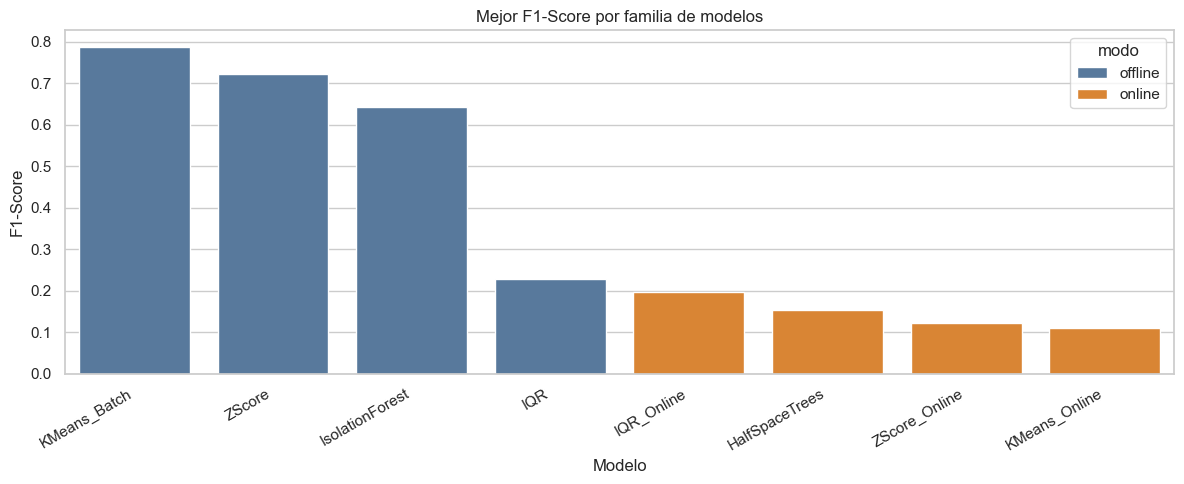

In [14]:
benchmark_df = pd.read_csv(BENCHMARK_PATH)
benchmark_df["modo"] = benchmark_df["model_type"].map(
    lambda name: "online" if "Online" in name or name == "HalfSpaceTrees" else "offline"
 )

best_per_model = (
    benchmark_df
    .sort_values(["f1_score", "recall", "precision"], ascending=False)
    .drop_duplicates(subset="model_type")
    .loc[:, [
        "model_type",
        "modo",
        "anomaly_def",
        "precision",
        "recall",
        "f1_score",
        "total_time_s",
        "mean_time_per_sample_ms",
        "n_outliers",
    ]]
    .sort_values(["modo", "f1_score"], ascending=[True, False])
    .reset_index(drop=True)
 )

display(best_per_model)

best_by_mode = (
    best_per_model.groupby("modo")[["precision", "recall", "f1_score", "mean_time_per_sample_ms"]]
    .mean()
    .round(4)
 )

display(best_by_mode)

plt.figure(figsize=(12, 5))
sns.barplot(data=best_per_model, x="model_type", y="f1_score", hue="modo", palette={"offline": "#4c78a8", "online": "#f58518"})
plt.title("Mejor F1-Score por familia de modelos")
plt.xlabel("Modelo")
plt.ylabel("F1-Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

,timestamp,gt_BROKEN+RECOVERING,KMeans_Batch_BROKEN+RECOVERING,ZScore_BROKEN+RECOVERING,IsolationForest_BROKEN+RECOVERING,IQR_BROKEN+RECOVERING,IQR_Online_BROKEN+RECOVERING,HalfSpaceTrees_BROKEN+RECOVERING,ZScore_Online_BROKEN+RECOVERING,KMeans_Online_BROKEN+RECOVERING
0,2018-04-01 00:00:00,0,0,0,0,0,0,0,0,0
1,2018-04-01 00:02:00,0,0,0,0,0,0,0,0,0
2,2018-04-01 00:03:00,0,0,0,0,0,0,0,0,0
3,2018-04-01 00:04:00,0,0,0,0,0,0,0,0,0
4,2018-04-01 00:05:00,0,0,0,0,0,0,0,0,0


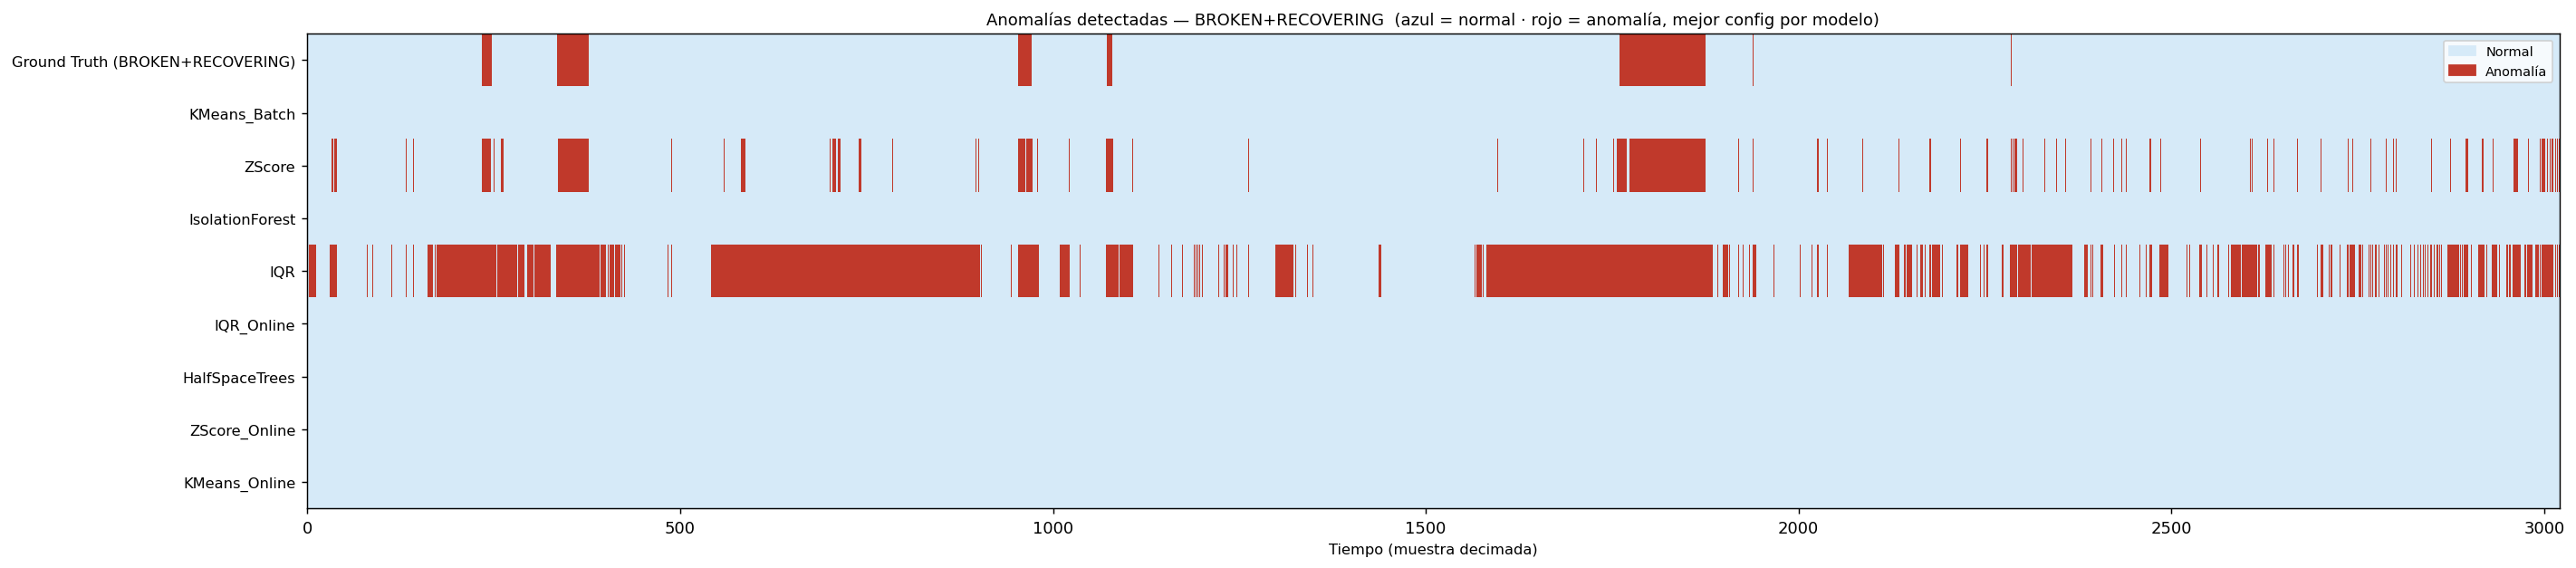

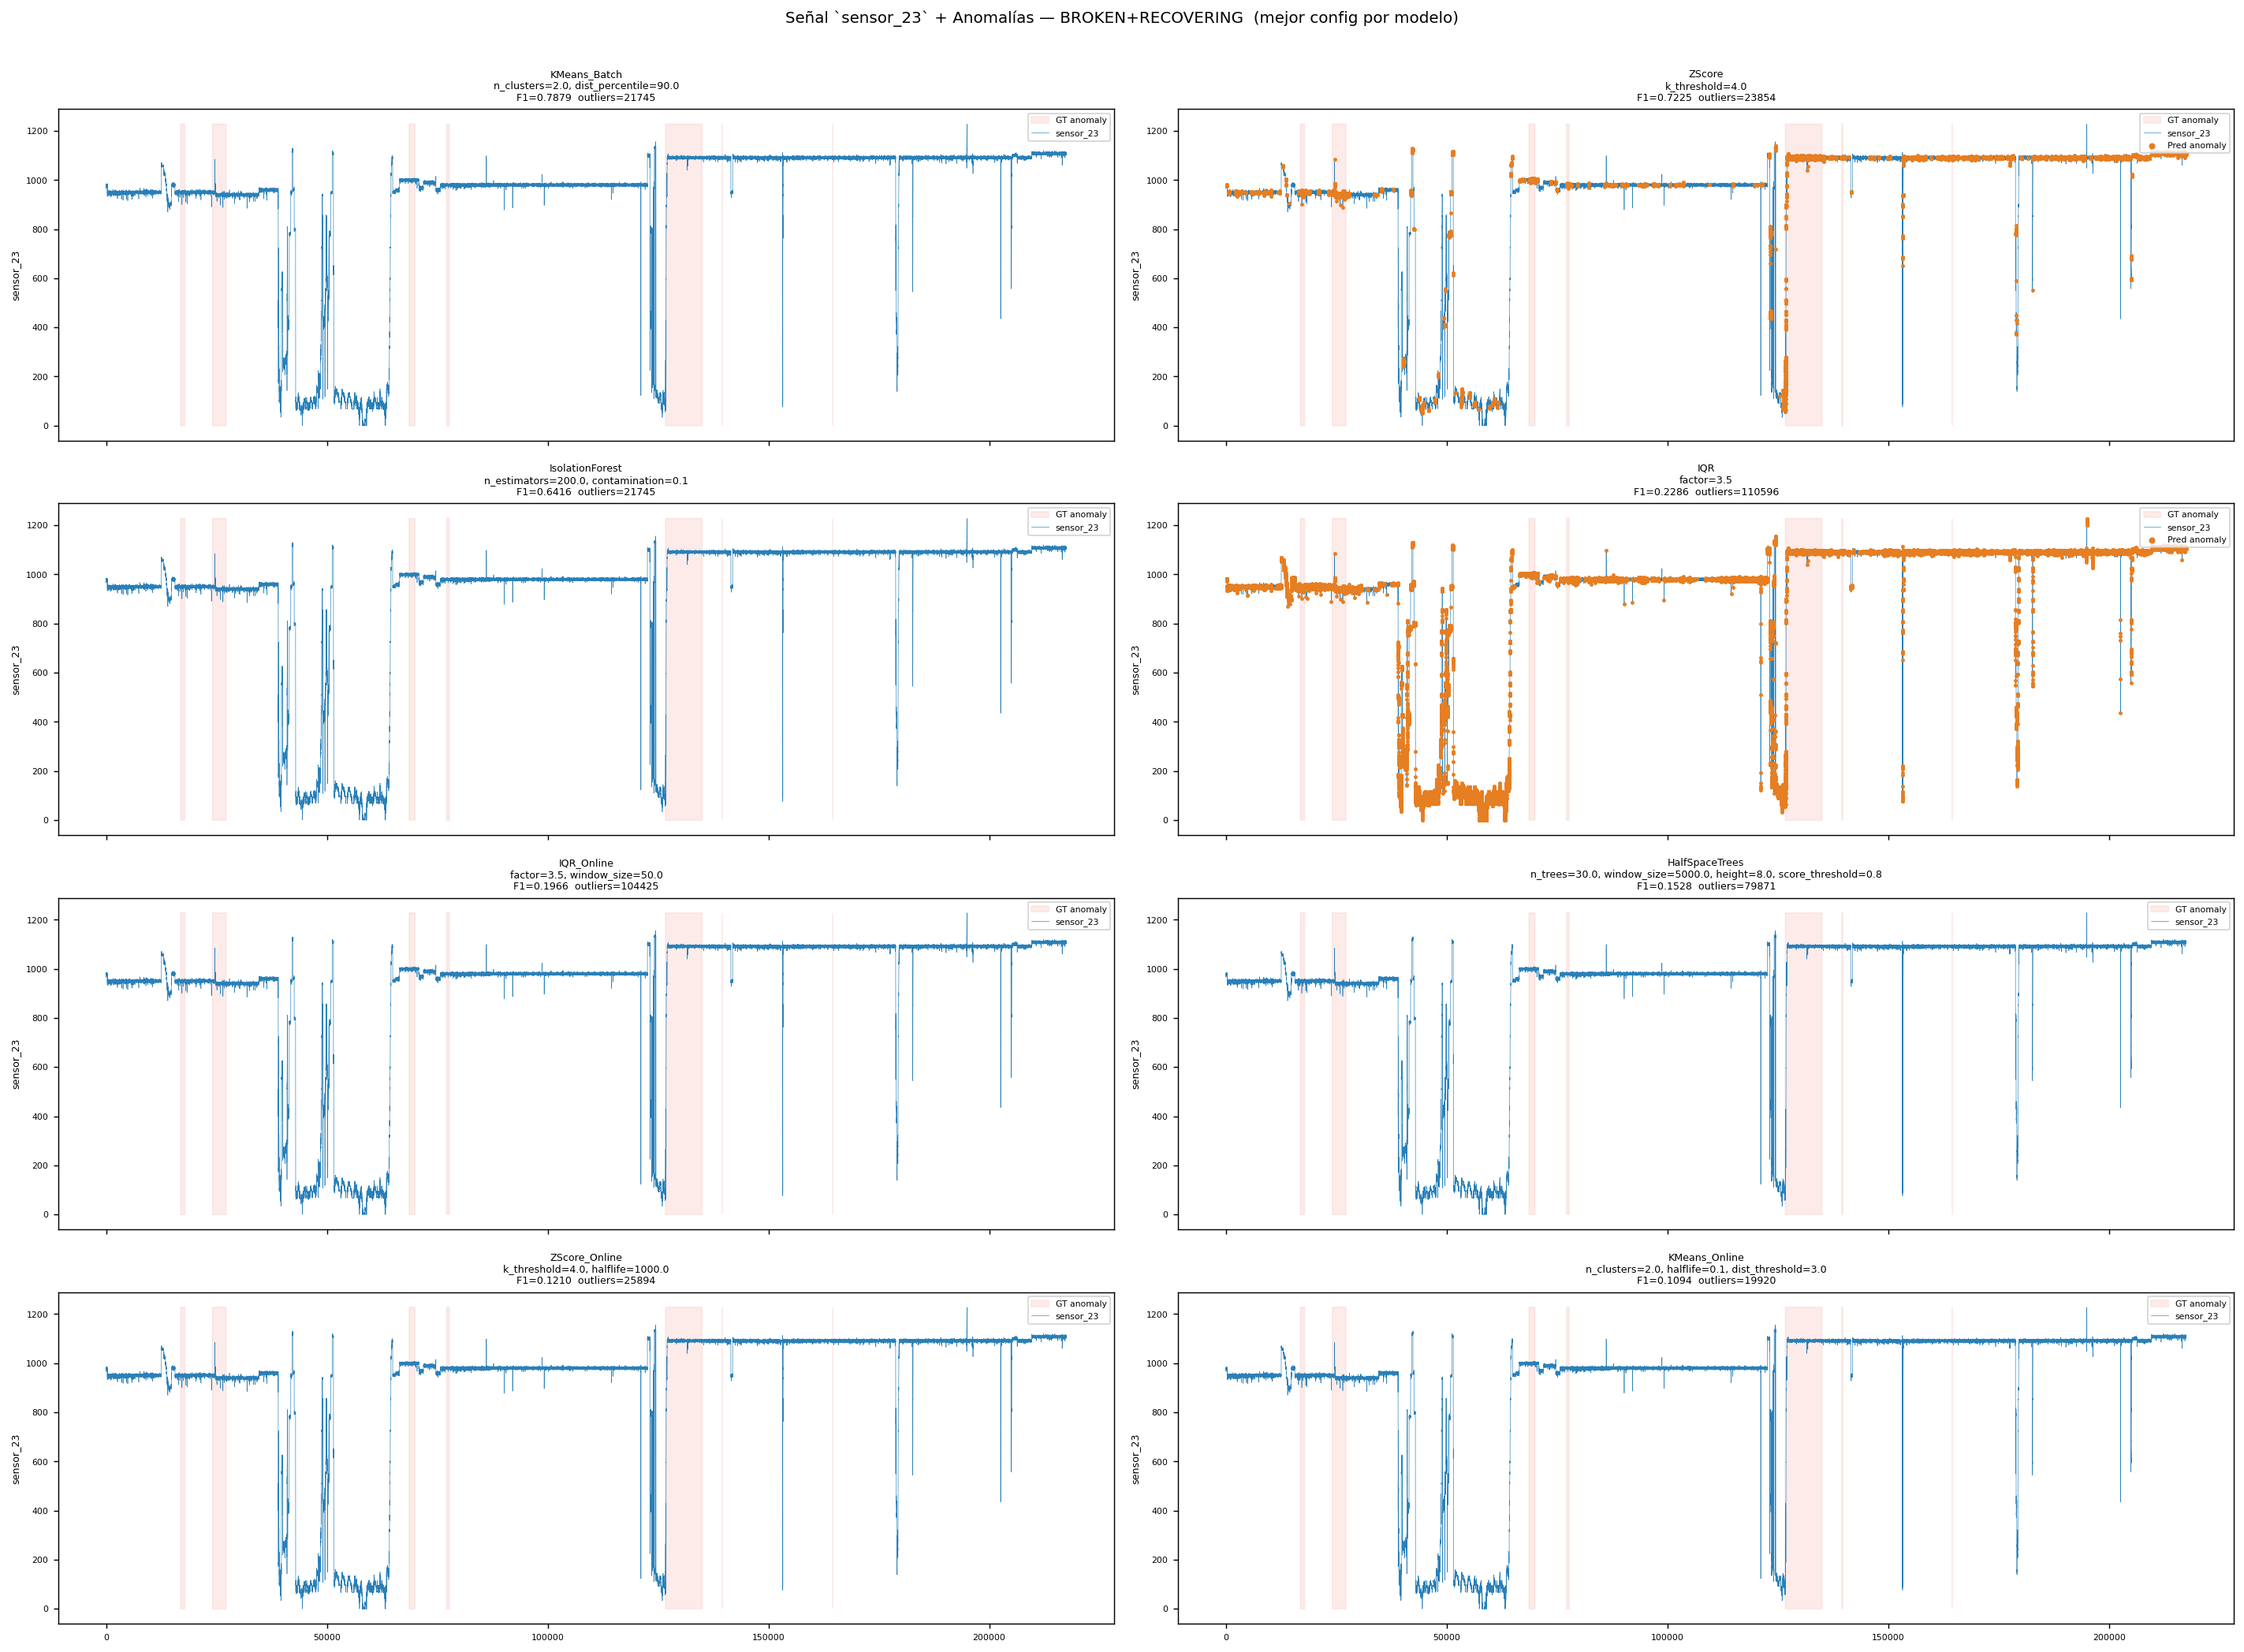

In [15]:
predictions_best = pd.read_csv(PREDICTIONS_PATH, parse_dates=["timestamp"])
display(predictions_best.head())

heatmap_path = PLOTS_DIR / "heatmap_BROKEN+RECOVERING.png"
timeline_path = PLOTS_DIR / "timeline_BROKEN+RECOVERING.png"

if heatmap_path.exists():
    display(Image(filename=str(heatmap_path)))

if timeline_path.exists():
    display(Image(filename=str(timeline_path)))

## Conclusiones 
### 1. Sobre la selección de sensores

La práctica parte de un sistema sensorizado multivariable. Por ello, la decisión metodológica más sólida es mantener todos los sensores útiles en el modelado y utilizar una única señal solo como apoyo interpretativo. Esta elección conserva la información global del proceso y evita simplificar en exceso un problema que depende de múltiples variables simultáneamente.

### 2. Sobre la selección de métodos

La combinación de técnicas responde a una lógica progresiva:

- **IQR y Z-Score** aportan líneas base estadísticas simples e interpretables.
- **K-Means batch** permite capturar estructura multivariante mediante distancias a centroides.
- **Isolation Forest** introduce un detector específicamente orientado a anomalías en datos históricos.
- **IQR online y Z-Score online** muestran cómo trasladar reglas estadísticas a un flujo continuo.
- **K-Means online y Half-Space Trees** representan enfoques incrementales más cercanos a un escenario de monitorización en tiempo real.

### 3. Sobre Offline vs Online

El contraste entre ambos escenarios muestra una diferencia importante: cuando se dispone del histórico completo, los detectores pueden estimar mejor la distribución del sistema y construir criterios de decisión más estables. En cambio, en streaming el modelo aprende progresivamente y su rendimiento depende más de la inicialización, la ventana temporal, la adaptación al cambio y la calibración de umbrales.

Por ello, si los métodos offline obtienen mejores métricas en esta práctica, la interpretación correcta no es que el enfoque online sea inútil, sino que requiere un ajuste más fino para funcionar bien bajo restricciones temporales y operativas.

### 4. Sobre la interpretación de resultados

En un entorno industrial no basta con detectar muchas anomalías. También es necesario controlar cuántas alertas son falsas, cuánto tarda en responder el método y si su mantenimiento resulta razonable. Por eso, la evaluación conjunta de precision, recall, F1 y tiempo de ejecución ofrece una lectura más realista que un único valor resumen.

